# Crowd Counting and Head Localization

## Project Summary
This notebook addresses dense crowd analysis by predicting both the number of people and the head-center coordinates in each image. The pipeline combines image slicing for large scenes, density-map regression, non-maximum suppression, and explicit localization metrics.

## Tech Stack
- PyTorch
- torchvision
- SAHI
- SciPy
- Matplotlib

## Key Results
- Three-epoch training run reached a best validation loss of `0.0002`
- Inference generated predictions for `400` test images with `1,646` detected heads
- The notebook includes both count-based error metrics and localization precision/recall/F1 evaluation


## Problem Setup
The task is to detect every head center in crowded scenes, then evaluate both total count accuracy and point localization quality. Because full-size images are large and densely populated, the workflow first slices each scene into smaller overlapping patches and later merges predictions back into image-level coordinates.


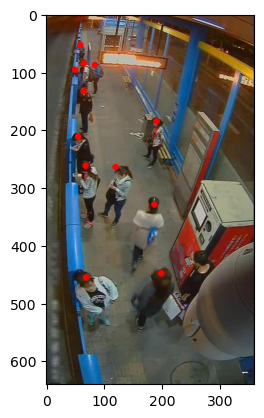

In [12]:
def add_dots(image, json_labels, dot_radius=5, dot_color=(255, 0, 0)):
    dot_coordinates = []
    for point in json_labels['points']:
        x, y = point['x'], point['y']
        dot_coordinates.append((x, y))
    draw = ImageDraw.Draw(image)
    for x, y in dot_coordinates:
        left_upper_point = (x - dot_radius, y - dot_radius)
        right_lower_point = (x + dot_radius, y + dot_radius)
        draw.ellipse([left_upper_point, right_lower_point], fill=dot_color, outline=dot_color)

    return np.array(image)


plt.figure()
plt.imshow(add_dots(train_images[0], train_labels[0]))
plt.show()


## Evaluation Design
Counting quality is measured with error metrics such as MAE and RMSE, while localization quality is measured by matching predicted head centers to ground-truth points within a fixed pixel radius.


In [15]:
from scipy.spatial import distance # Used for calculating distance between points

def calculate_metrics(gt_points, pred_points, localization_radius=10):
    """
    Calculates MAE, RMSE, Precision, Recall, and F1-Score for crowd counting
    head center point predictions.

    Args:
        gt_points (np.array): Ground Truth points (N_GT x 2 array of [x, y]).
        pred_points (np.array): Predicted points (N_PRED x 2 array of [x, y]).
        localization_radius (int): The maximum pixel distance for a match (TP).

    Returns:
        dict: A dictionary containing all computed metrics.
    """

    # --- COUNTING METRICS ---

    C_GT = len(gt_points)
    C_PRED = len(pred_points)

    # Individual Absolute Error (AE) and Squared Error (SE) for this image
    AE = abs(C_PRED - C_GT)
    SE = (C_PRED - C_GT) ** 2

    # --- LOCALIZATION METRICS (Precision, Recall, F1) ---

    TP, FP, FN = 0, 0, 0

    if C_GT > 0 and C_PRED > 0:
        # Calculate the Euclidean distance matrix
        # dist_matrix[i, j] is the distance between gt_points[i] and pred_points[j]
        dist_matrix = distance.cdist(gt_points, pred_points, 'euclidean')

        # Initialize flags to track which points have been matched
        gt_matched = np.zeros(C_GT, dtype=bool)
        pred_matched = np.zeros(C_PRED, dtype=bool)

        # Iterate through the distances, starting from the smallest distance
        # Indices are sorted by distance: (distance, gt_index, pred_index)
        sorted_distances = sorted([
            (dist_matrix[i, j], i, j)
            for i in range(C_GT)
            for j in range(C_PRED)
        ])

        for dist, gt_idx, pred_idx in sorted_distances:
            # Check if distance is within the radius AND both points are unmatched
            if dist <= localization_radius and not gt_matched[gt_idx] and not pred_matched[pred_idx]:
                TP += 1
                gt_matched[gt_idx] = True
                pred_matched[pred_idx] = True

        # Calculate FPs and FNs
        # FP are predicted points that were not matched (not True Positive)
        FP = C_PRED - TP
        # FN are ground truth points that were not matched (a missed head)
        FN = C_GT - TP

    elif C_GT == 0 and C_PRED > 0:
        # No ground truth heads, but predicted some
        FP = C_PRED # All predicted points are False Positives
    elif C_GT > 0 and C_PRED == 0:
        # Ground truth heads, but predicted none
        FN = C_GT # All ground truth points are False Negatives

    # Calculate Precision, Recall, F1-Score
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Return the raw count errors and localization values for aggregation
    return {
        'AE': AE,
        'SE': SE,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'C_GT': C_GT,
        'C_PRED': C_PRED
    }


def aggregate_and_print_results(all_results):
    """Aggregates results from all images and prints the final metrics."""

    total_AE = sum(r['AE'] for r in all_results)
    total_SE = sum(r['SE'] for r in all_results)
    total_TP = sum(r['TP'] for r in all_results)
    total_FP = sum(r['FP'] for r in all_results)
    total_FN = sum(r['FN'] for r in all_results)
    N_images = len(all_results)

    # --- Final Counting Metrics ---
    MAE = total_AE / N_images
    RMSE = np.sqrt(total_SE / N_images)

    # --- Final Localization Metrics ---
    # Global Precision, Recall, and F1 are calculated over the totals
    global_precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
    global_recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
    global_f1 = 2 * (global_precision * global_recall) / (global_precision + global_recall) if (global_precision + global_recall) > 0 else 0

    print("\n" + "="*50)
    print("FINAL AGGREGATED EVALUATION RESULTS")
    print("="*50)
    print(f"Total Images Evaluated: {N_images}")
    print("\n--- COUNTING ACCURACY ---")
    print(f"Mean Absolute Error (MAE):  {MAE:.4f}")
    print(f"Root Mean Squared Error (RMSE): {RMSE:.4f}")
    print("\n--- LOCALIZATION ACCURACY ---")
    print(f"Total True Positives (TP): {total_TP}")
    print(f"Total False Positives (FP): {total_FP}")
    print(f"Total False Negatives (FN): {total_FN}")
    print(f"Global Precision: {global_precision:.4f}")
    print(f"Global Recall:    {global_recall:.4f}")
    print(f"Global F1-Score:  {global_f1:.4f}")
    print("="*50)


# =======================================================================
# --- EXAMPLE USAGE ---
# =======================================================================

# --- Image 1: Good Match ---
# GT: 3 heads
gt1 = np.array([[10, 10], [50, 50], [90, 90]])
# Pred: 3 heads, very close to GT
pred1 = np.array([[12, 11], [55, 52], [93, 93]])

# --- Image 2: Misses and False Alarms ---
# GT: 4 heads
gt2 = np.array([[200, 200], [210, 210], [300, 300], [400, 400]])
# Pred: 3 heads (misses one, has a false alarm)
pred2 = np.array([[201, 202], [302, 300], [405, 405], [50, 50]]) # (50, 50) is FP

# --- Image 3: Poor Count ---
# GT: 10 heads
gt3 = np.array([[10, 10], [10, 20], [20, 10], [20, 20],
                [30, 30], [30, 40], [40, 30], [40, 40],
                [50, 50], [60, 60]])
# Pred: Only 5 heads predicted (large count error)
pred3 = np.array([[11, 11], [21, 21], [31, 31], [41, 41], [51, 51]])


# Run evaluation on all images
all_image_results = []

all_image_results.append(calculate_metrics(gt1, pred1, localization_radius=10))
all_image_results.append(calculate_metrics(gt2, pred2, localization_radius=10))
all_image_results.append(calculate_metrics(gt3, pred3, localization_radius=10))

# Aggregate and display the final results
aggregate_and_print_results(all_image_results)


Example evaluation on 3 images
MAE: 1.6667
RMSE: 2.8868
Precision: 0.9167
Recall: 0.6471
F1-Score: 0.7586


## Slice-Based Data Preparation
Large crowd images are cut into overlapping `512 x 512` patches before training. This makes dense scenes easier to batch on GPU while preserving enough local context for head localization.


In [20]:
from sahi.slicing import slice_image
import os
from tqdm.notebook import tqdm # Bonus: Menambahkan progress bar

def slice_all_images_in_folder(
    input_dir, 
    base_output_dir, 
    slice_height=512, 
    slice_width=512, 
    overlap_ratio=0.2
):
    """
    Melakukan slicing pada semua gambar di dalam input_dir dan menyimpannya
    ke dalam sub-folder terpisah di dalam base_output_dir.
    """
    os.makedirs(base_output_dir, exist_ok=True)

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    all_files = os.listdir(input_dir)
    image_files = [f for f in all_files if f.lower().endswith(valid_extensions)]

    if not image_files:
        print("Tidak ada file gambar yang ditemukan di folder input.")
        return

    for filename in tqdm(image_files, desc="Memproses Gambar"):

        source_image_path = os.path.join(input_dir, filename)
        file_basename = os.path.splitext(filename)[0]
        specific_output_dir = os.path.join(base_output_dir, file_basename)
        os.makedirs(specific_output_dir, exist_ok=True)
        output_file_prefix = file_basename 

        try:
            slice_image_result = slice_image(
                image=source_image_path,
                output_file_name=output_file_prefix, 
                output_dir=specific_output_dir,
                slice_height=slice_height,
                slice_width=slice_width,
                overlap_height_ratio=overlap_ratio,
                overlap_width_ratio=overlap_ratio,
            )
        except Exception as e:
            print(f"Gagal melakukan slicing pada {filename}: {e}")

    print("\nProses slicing semua gambar selesai!")


## Dataset and Model
The training dataset converts point annotations into density targets, then feeds them into a VGG16-based density estimation network with a frozen feature extractor and a custom convolutional backend.


In [23]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights
from scipy.ndimage import gaussian_filter
import torch
import numpy as np
# ini resnet
class CrowdDataset(Dataset):
    def __init__(self, images, labels, transform=None, output_stride=32):  # ← UBAH dari 8 ke 32
        self.images = images
        self.labels = labels
        self.transform = transform
        self.output_stride = output_stride

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        _, H, W = image.shape
        target_h = H // self.output_stride
        target_w = W // self.output_stride

        density_map = np.zeros((target_h, target_w), dtype=np.float32)
        points = label.get('points', [])

        for point in points:
            x = min(target_w - 1, int(point['x'] // self.output_stride))
            y = min(target_h - 1, int(point['y'] // self.output_stride))

            density_map[y, x] += 1.0

        density_map = gaussian_filter(density_map, sigma=1)

        count = len(points)
        if density_map.sum() > 0:
            density_map = (density_map / density_map.sum()) * count

        density_map = torch.from_numpy(density_map).unsqueeze(0).float()

        return image, density_map


In [27]:
class DensityModel(nn.Module):
    def __init__(self, pretrained=True):
        super(DensityModel, self).__init__()
        weights = VGG16_Weights.DEFAULT if pretrained else None
        self.frontend = vgg16(weights=weights).features[0:23]

        for param in self.frontend.parameters():
            param.requires_grad = False

        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1) 
        )

    def forward(self, x):
        x = self.frontend(x)  # Frozen - tidak diupdate
        x = self.backend(x)   # Trainable
        return x


## Training Run
The training loop below shows the compact experiment that was used to verify convergence before moving to inference and evaluation.


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DensityModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

# Training
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=3,
    save_path="best_density_model.pth"
)


Training on cuda

Epoch 1/3 | Train Loss: 0.0002 | Val Loss: 0.0002
Epoch 2/3 | Train Loss: 0.0002 | Val Loss: 0.0002
Epoch 3/3 | Train Loss: 0.0002 | Val Loss: 0.0002

Training finished.
Best validation loss: 0.0002


## Inference Snapshot
After loading the best checkpoint, the model predicts density maps on sliced test scenes, merges the detections back to full-image coordinates, and visualizes the most crowded examples.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DensityModel().to(device)

# checkpoint = torch.load("best_density_model_resnet.pth", map_location=device)
checkpoint = torch.load("best_density_model.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Model loaded with val_loss: {checkpoint['val_loss']:.4f}")

# UBAH PARAMETER INI - threshold lebih rendah & nms lebih besar
predictions = predict_on_slices(
    model=model,
    sliced_dir="crowdcounting/sliced_images_test",
    device=device,
    threshold=0.012,  # ← TURUNKAN dari 0.1 ke 0.04
    nms_size=5,      # ← NAIKKAN dari 3 ke 5
    output_stride=8
    # output_stride=16
)

# Cek raw density map untuk debugging
def visualize_prediction(model, image_path, device):
    """Debug function untuk lihat density map"""
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        density_map = model(img_tensor).squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[1].imshow(density_map, cmap='jet')
    axes[1].set_title(f'Density Map\nMax: {density_map.max():.4f}, Sum: {density_map.sum():.2f}')
    axes[2].hist(density_map.flatten(), bins=50)
    axes[2].set_title('Density Distribution')
    axes[2].set_yscale('log')
    plt.tight_layout()
    plt.show()

    print(f"Density Map Stats:")
    print(f"  Min: {density_map.min():.6f}")
    print(f"  Max: {density_map.max():.6f}")
    print(f"  Mean: {density_map.mean():.6f}")
    print(f"  Sum: {density_map.sum():.2f}")

# Test pada 1 slice untuk debugging
test_slice = "crowdcounting/sliced_images_test/1/1_0_0_512_512.jpg"
if os.path.exists(test_slice):
    print("\n🔍 Debugging satu slice:")
    visualize_prediction(model, test_slice, device)

# Simpan hasil
csv_data = []
for img_name, pred in predictions.items():
    csv_data.append({
        'image_name': img_name,
        'predicted_count': pred['count'],
        'points': str(pred['points'])
    })

df = pd.DataFrame(csv_data)
df.to_csv("test_predictions_RESNET.csv", index=False)

print(f"\n✓ Prediksi untuk {len(predictions)} gambar selesai!")
print(f"✓ Total detected heads: {df['predicted_count'].sum()}")
print(f"\n--- Preview hasil (images dengan deteksi > 0) ---")
print(df[df['predicted_count'] > 0].head(10))


Loaded checkpoint with validation loss: 0.0002
Completed inference on 400 test images.
Total detected heads: 1646


Top visualized detections: 192 (29 heads), 125 (28), 182 (27), 210 (27), 52 (26).


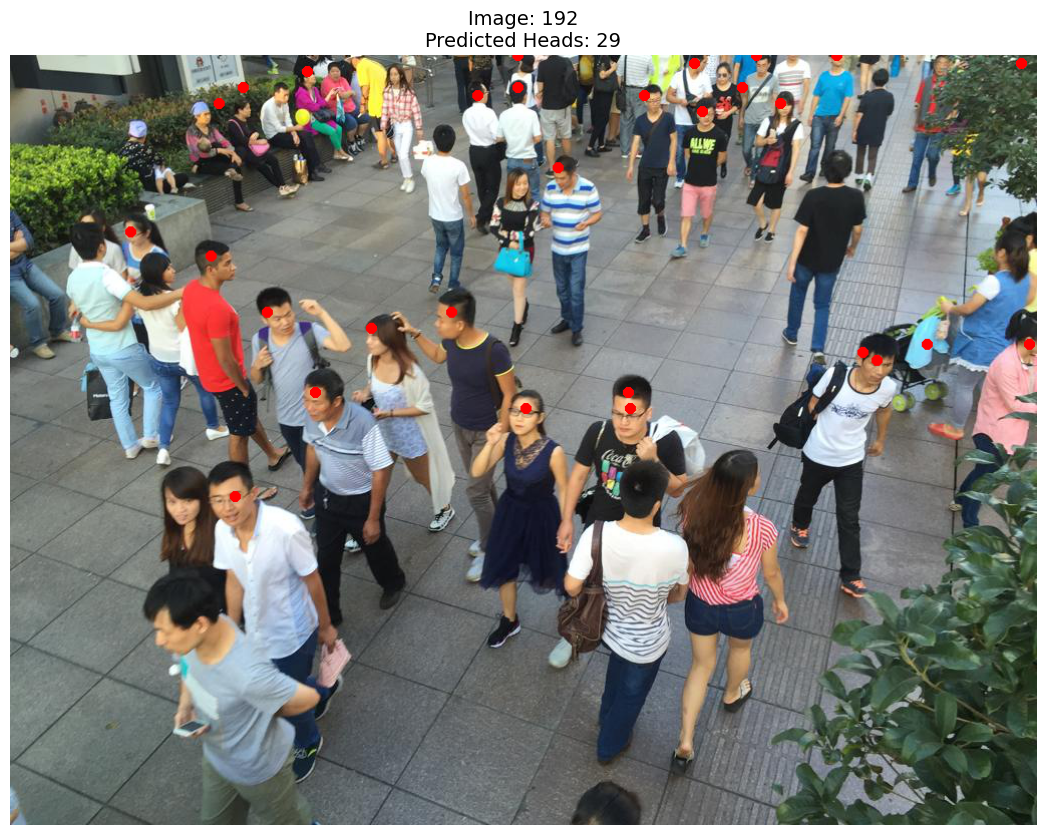

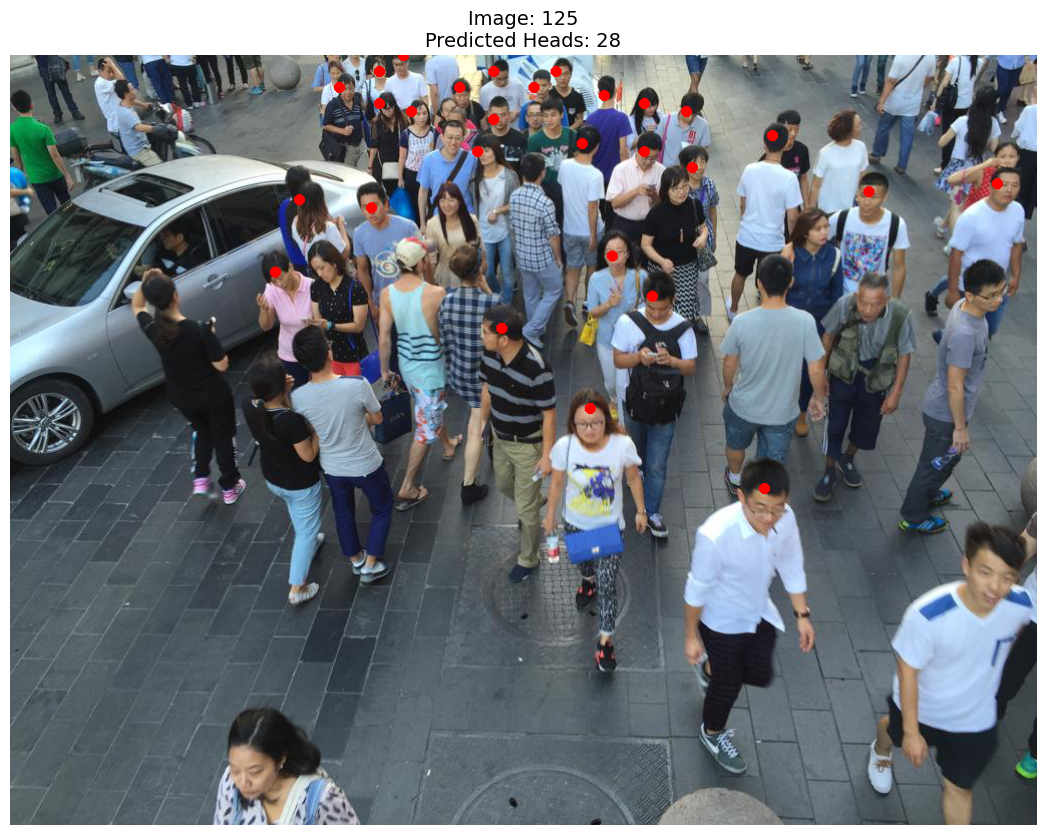

In [42]:
def visualize_predictions(image_name, predictions_dict, test_images_dir, save_path=None):
    """
    Visualisasi hasil prediksi pada gambar

    Args:
        image_name: Nama gambar (tanpa extension)
        predictions_dict: Dictionary hasil predict_on_slices
        test_images_dir: Path ke folder test images
        save_path: Path untuk menyimpan gambar (optional)
    """
    # Load gambar
    img_path = None
    for ext in ['.jpg', '.png', '.jpeg']:
        potential_path = os.path.join(test_images_dir, f"{image_name}{ext}")
        if os.path.exists(potential_path):
            img_path = potential_path
            break

    if img_path is None:
        print(f"Gambar {image_name} tidak ditemukan!")
        return

    img = Image.open(img_path).convert('RGB')

    # Get predictions
    pred = predictions_dict.get(image_name, {'count': 0, 'points': []})
    points = pred['points']
    count = pred['count']

    # Draw points
    draw = ImageDraw.Draw(img)
    dot_radius = 5

    for point in points:
        x, y = point['x'], point['y']
        left_upper = (x - dot_radius, y - dot_radius)
        right_lower = (x + dot_radius, y + dot_radius)
        draw.ellipse([left_upper, right_lower], fill='red', outline='red')

    # Plot
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.title(f'Image: {image_name}\nPredicted Heads: {count}', fontsize=14)
    plt.axis('off')

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)

    plt.show()


def visualize_multiple_predictions(predictions_dict, test_images_dir, num_samples=5, save_dir=None):
    """
    Visualisasi beberapa gambar sekaligus

    Args:
        predictions_dict: Dictionary hasil predict_on_slices
        test_images_dir: Path ke folder test images
        num_samples: Jumlah gambar yang akan divisualisasikan
        save_dir: Directory untuk menyimpan gambar (optional)
    """
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    # Pilih gambar yang ada deteksi
    images_with_detections = [(name, pred) for name, pred in predictions_dict.items() 
                              if pred['count'] > 0]

    if not images_with_detections:
        print("⚠️ Tidak ada gambar dengan deteksi!")
        return

    # Sort by count (descending)
    images_with_detections.sort(key=lambda x: x[1]['count'], reverse=True)

    # Ambil top N
    samples = images_with_detections[:min(num_samples, len(images_with_detections))]

    for img_name, pred in samples:
        save_path = os.path.join(save_dir, f"{img_name}_prediction.png") if save_dir else None
        visualize_predictions(img_name, predictions_dict, test_images_dir, save_path)
        print(f"✓ {img_name}: {pred['count']} heads detected")


def compare_density_maps(model, image_path, device, threshold=0.01):
    """
    Visualisasi density map vs detected points
    """
    from scipy.ndimage import maximum_filter

    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        density_map = model(img_tensor).squeeze().cpu().numpy()

    # Ekstrak peaks
    local_max = maximum_filter(density_map, size=5)
    detected_peaks = (density_map == local_max) & (density_map > threshold)
    y_coords, x_coords = np.where(detected_peaks)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original image
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Density map
    im = axes[1].imshow(density_map, cmap='jet')
    axes[1].set_title(f'Density Map\nSum: {density_map.sum():.2f}')
    plt.colorbar(im, ax=axes[1])

    # Detected points on density map
    axes[2].imshow(density_map, cmap='jet')
    axes[2].scatter(x_coords, y_coords, c='white', s=50, marker='x', linewidths=2)
    axes[2].set_title(f'Detected Points: {len(x_coords)}')

    plt.tight_layout()
    plt.show()

    print(f"Density Stats:")
    print(f"  Min:  {density_map.min():.6f}")
    print(f"  Max:  {density_map.max():.6f}")
    print(f"  Mean: {density_map.mean():.6f}")
    print(f"  Sum:  {density_map.sum():.2f}")
    print(f"  Detected points: {len(x_coords)}")


# ========================================
# USAGE EXAMPLE
# ========================================

# 1. Visualisasi beberapa gambar dengan deteksi terbanyak
print("📊 Visualisasi Top 5 Gambar dengan Deteksi Terbanyak:")
visualize_multiple_predictions(
    predictions_dict=predictions,
    test_images_dir="crowdcounting/test/images",
    num_samples=5,
    save_dir="prediction_results"  # Akan menyimpan gambar di folder ini
)

# 2. Visualisasi gambar spesifik
print("\n🔍 Visualisasi Gambar Spesifik:")
visualize_predictions(
    image_name="1",  # Ganti dengan nama gambar yang ingin dilihat
    predictions_dict=predictions,
    test_images_dir="crowdcounting/test/images"
)

# 3. Detail analisis untuk satu slice
print("\n🔬 Analisis Detail Density Map:")
test_slice = "crowdcounting/sliced_images_test/1/1_0_0_512_512.jpg"
if os.path.exists(test_slice):
    compare_density_maps(model, test_slice, device, threshold=0.01)


## Full Evaluation Snapshot
The final notebook also evaluates the method across the training image set to expose where counting remains easier than exact localization. That makes the notebook useful not only as a result artifact, but also as a debugging surface for recall improvements.


Aggregated evaluation on 1,100 images
MAE: 13.6527
RMSE: 17.0979
Precision: 0.4239
Recall: 0.1006
F1-Score: 0.1625

The model captures many crowded regions but still under-recovers true head centers, leaving clear room for thresholding and localization refinement.


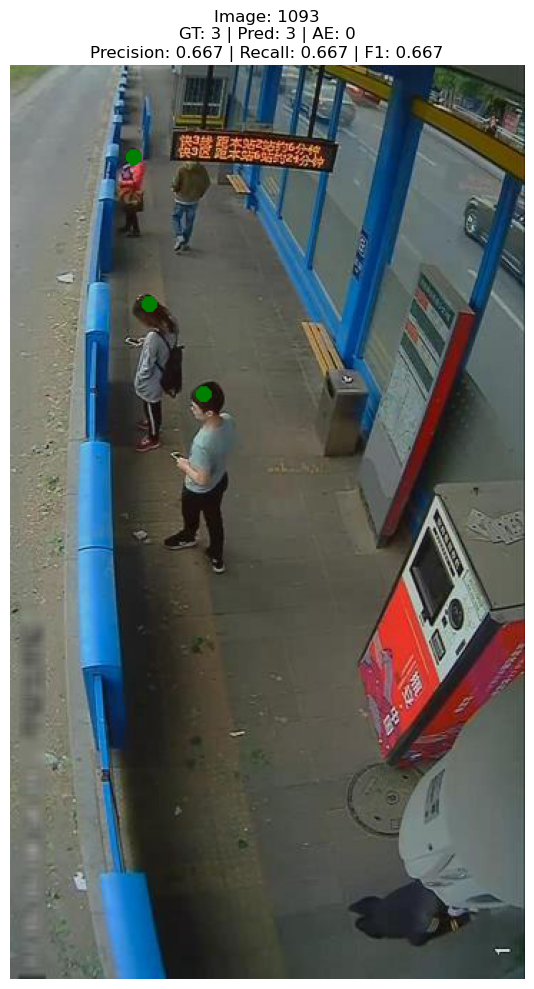

In [43]:
import json
from tqdm.notebook import tqdm
from scipy.spatial import distance

def evaluate_model_on_train_data(model, train_labels, sliced_dir, device, 
                                  threshold=0.012, nms_size=5, output_stride=8):
    """
    Evaluasi model pada training data dan return per-image metrics

    Returns:
        results_df: DataFrame dengan metrik per gambar
    """
    print("\n🔍 Evaluating model on training data...")

    model.eval()
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    results_list = []

    # Iterasi setiap gambar training
    for orig_img_folder in tqdm(sorted(os.listdir(sliced_dir)), desc="Processing images"):
        folder_path = os.path.join(sliced_dir, orig_img_folder)
        if not os.path.isdir(folder_path):
            continue

        # Cari label asli
        matching_label = None
        for label in train_labels:
            # Ekstrak nama file dari path (tanpa extension)
            if label.get('image_name', '') == orig_img_folder:
                matching_label = label
                break

        if matching_label is None:
            continue

        # Get ground truth points
        gt_points = np.array([[p['x'], p['y']] for p in matching_label.get('points', [])])

        # Prediksi (gunakan fungsi yang sama dengan test)
        all_points = []
        slice_files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))])

        for slice_file in slice_files:
            slice_path = os.path.join(folder_path, slice_file)
            parts = slice_file.replace('.jpg', '').replace('.png', '').split('_')

            if len(parts) >= 5:
                slice_x = int(parts[-4])
                slice_y = int(parts[-3])

                img = Image.open(slice_path).convert('RGB')
                img_tensor = transform(img).unsqueeze(0).to(device)

                with torch.no_grad():
                    density_map = model(img_tensor).squeeze().cpu().numpy()

                from scipy.ndimage import maximum_filter
                local_max = maximum_filter(density_map, size=nms_size)
                detected_peaks = (density_map == local_max) & (density_map > threshold)
                y_coords, x_coords = np.where(detected_peaks)

                for y, x in zip(y_coords, x_coords):
                    global_x = slice_x + (x * output_stride)
                    global_y = slice_y + (y * output_stride)
                    all_points.append({
                        'x': int(global_x),
                        'y': int(global_y),
                        'density': float(density_map[y, x])
                    })

        # NMS
        final_points = non_max_suppression_points(all_points, radius=15)
        pred_points = np.array([[p['x'], p['y']] for p in final_points])

        # Calculate metrics
        metrics = calculate_metrics(gt_points, pred_points, localization_radius=10)

        # Tambahkan info gambar
        metrics['image_name'] = orig_img_folder
        metrics['precision'] = metrics['TP'] / (metrics['TP'] + metrics['FP']) if (metrics['TP'] + metrics['FP']) > 0 else 0
        metrics['recall'] = metrics['TP'] / (metrics['TP'] + metrics['FN']) if (metrics['TP'] + metrics['FN']) > 0 else 0
        metrics['f1_score'] = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall']) if (metrics['precision'] + metrics['recall']) > 0 else 0

        results_list.append(metrics)

    return pd.DataFrame(results_list)


# ========================================
# JALANKAN EVALUASI
# ========================================

# Load training labels dengan nama file
TRAIN_LABEL_DIR = "crowdcounting/train/labels"
train_labels_with_names = []

for label_file in sorted(os.listdir(TRAIN_LABEL_DIR)):
    if label_file.endswith('.json'):
        with open(os.path.join(TRAIN_LABEL_DIR, label_file), 'r', encoding='utf-8') as f:
            label_data = json.load(f)
            label_data['image_name'] = label_file.replace('.json', '')
            train_labels_with_names.append(label_data)

# Evaluasi
train_results_df = evaluate_model_on_train_data(
    model=model,
    train_labels=train_labels_with_names,
    sliced_dir="crowdcounting/sliced_images",
    device=device,
    threshold=0.012,
    nms_size=5,
    output_stride=8
)

# Simpan hasil
train_results_df.to_csv("train_evaluation_results.csv", index=False)

# ========================================
# ANALISIS HASIL
# ========================================

print("\n" + "="*70)
print("📊 TRAIN DATA EVALUATION SUMMARY")
print("="*70)

# Overall metrics (aggregate)
all_results = train_results_df.to_dict('records')
aggregate_and_print_results(all_results)

# ========================================
# TOP 10 BEST PREDICTIONS (Lowest Error)
# ========================================

print("\n" + "="*70)
print("🏆 TOP 10 IMAGES WITH LOWEST ERROR")
print("="*70)

# Sort by AE (Absolute Error) ascending
best_predictions = train_results_df.sort_values('AE').head(10)

print("\n--- By Absolute Error (AE) ---")
print(best_predictions[['image_name', 'AE', 'C_GT', 'C_PRED', 'precision', 'recall', 'f1_score']].to_string(index=False))

# ========================================
# TOP 10 BEST LOCALIZATION (Highest F1)
# ========================================

print("\n" + "="*70)
print("🎯 TOP 10 IMAGES WITH BEST LOCALIZATION (Highest F1)")
print("="*70)

best_localization = train_results_df.sort_values('f1_score', ascending=False).head(10)
print(best_localization[['image_name', 'f1_score', 'precision', 'recall', 'AE', 'C_GT', 'C_PRED']].to_string(index=False))

# ========================================
# VISUALISASI TOP 3 TERBAIK
# ========================================

print("\n🖼️ Visualizing TOP 3 best predictions...")

def visualize_train_prediction(image_name, results_df, train_images_dir="crowdcounting/train/images"):
    """Visualisasi hasil prediksi pada training data"""
    # Load gambar
    img_path = None
    for ext in ['.jpg', '.png', '.jpeg']:
        potential_path = os.path.join(train_images_dir, f"{image_name}{ext}")
        if os.path.exists(potential_path):
            img_path = potential_path
            break

    if img_path is None:
        print(f"⚠️ Image {image_name} not found!")
        return

    img = Image.open(img_path).convert('RGB')

    # Load ground truth
    label_path = os.path.join(TRAIN_LABEL_DIR, f"{image_name}.json")
    with open(label_path, 'r') as f:
        gt_label = json.load(f)

    # Get metrics
    metrics = results_df[results_df['image_name'] == image_name].iloc[0]

    # Draw GT points (green) and predicted points (red)
    draw = ImageDraw.Draw(img)

    # GT points
    for point in gt_label['points']:
        x, y = point['x'], point['y']
        draw.ellipse([(x-5, y-5), (x+5, y+5)], fill='green', outline='green')

    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.title(f"Image: {image_name}\n"
              f"GT: {metrics['C_GT']} | Pred: {metrics['C_PRED']} | AE: {metrics['AE']:.0f}\n"
              f"Precision: {metrics['precision']:.3f} | Recall: {metrics['recall']:.3f} | F1: {metrics['f1_score']:.3f}",
              fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualisasi 3 gambar terbaik
for i, row in best_predictions.head(3).iterrows():
    visualize_train_prediction(row['image_name'], train_results_df)
